In [1]:
from dataclasses import dataclass

from pathlib import Path

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

# Works whether the notebook is run from the project root

# or from the notebooks/ directory.

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":

    PROJECT_ROOT = CURRENT_DIR.parent

else:

    PROJECT_ROOT = CURRENT_DIR

FIGURE_DIR = PROJECT_ROOT / "results" / "figures"

TABLE_DIR = PROJECT_ROOT / "results" / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

print("Figure directory:", FIGURE_DIR)

print("Table directory:", TABLE_DIR)

Project root: /Users/zhulongdi/when-is-a-fill-bad
Figure directory: /Users/zhulongdi/when-is-a-fill-bad/results/figures
Table directory: /Users/zhulongdi/when-is-a-fill-bad/results/tables


In [2]:
@dataclass

class SimulationConfig:

    # Simulation horizon

    n_steps: int = 100

    post_fill_horizon: int = 20

    # Market state

    initial_mid_price: float = 100.0

    spread: float = 0.02

    queue_ahead: float = 8.0

    imbalance: float = 0.0

    volatility: float = 0.008

    # Queue dynamics

    base_market_sell_rate: float = 0.25

    cancellation_rate: float = 0.05

    pressure_sensitivity: float = 1.0

    # Price dynamics

    drift_coefficient: float = 0.01

    # Reproducibility

    seed: int = 0

def run_single_simulation(config: SimulationConfig) -> dict:

    """

    Simulate one passive buy order.

    Interpretation:

    - Negative imbalance means the bid side is relatively weak.

    - Negative imbalance increases market-sell intensity.

    - Negative imbalance also produces negative expected mid-price drift.

    - The passive buy earns half-spread at execution.

    - A fill is bad when post-fill price decline exceeds the half-spread.

    """

    rng = np.random.default_rng(config.seed)

    mid_price = config.initial_mid_price

    queue_remaining = config.queue_ahead

    fill_time = None

    fill_mid_price = np.nan

    fill_price = np.nan

    mid_price_history = []

    # Negative imbalance increases market-sell pressure.

    market_sell_intensity = (

        config.base_market_sell_rate

        * np.exp(-config.pressure_sensitivity * config.imbalance)

    )

    for step in range(config.n_steps):

        market_sell_volume = rng.poisson(market_sell_intensity)

        cancellation_volume = rng.poisson(config.cancellation_rate)

        # Queue evolution before the order fills.

        if fill_time is None:

            queue_remaining -= (

                market_sell_volume + cancellation_volume

            )

            if queue_remaining <= 0:

                fill_time = step

                fill_mid_price = mid_price

                fill_price = (

                    fill_mid_price - config.spread / 2.0

                )

        # Persistent imbalance drift plus symmetric noise.

        deterministic_drift = (

            config.drift_coefficient * config.imbalance

        )

        random_move = (

            config.volatility * rng.normal()

        )

        mid_price += deterministic_drift + random_move

        mid_price_history.append(mid_price)

    # A valid observation needs enough data after the fill.

    valid_fill = (

        fill_time is not None

        and fill_time + config.post_fill_horizon

        <= config.n_steps

    )

    if valid_fill:

        post_fill_index = (

            fill_time + config.post_fill_horizon - 1

        )

        post_fill_mid_price = (

            mid_price_history[post_fill_index]

        )

        post_fill_drift = (

            post_fill_mid_price - fill_mid_price

        )

        spread_capture = (

            fill_mid_price - fill_price

        )

        adverse_drift = max(

            0.0,

            -post_fill_drift,

        )

        net_execution_value = (

            spread_capture + post_fill_drift

        )

        bad_fill = net_execution_value < 0

    else:

        post_fill_mid_price = np.nan

        post_fill_drift = np.nan

        spread_capture = np.nan

        adverse_drift = np.nan

        net_execution_value = np.nan

        bad_fill = False

    return {

        "filled": valid_fill,

        "fill_time": fill_time,

        "fill_mid_price": fill_mid_price,

        "fill_price": fill_price,

        "post_fill_mid_price": post_fill_mid_price,

        "post_fill_drift": post_fill_drift,

        "spread_capture": spread_capture,

        "adverse_drift": adverse_drift,

        "net_execution_value": net_execution_value,

        "bad_fill": bad_fill,

        "queue_ahead": config.queue_ahead,

        "imbalance": config.imbalance,

        "volatility": config.volatility,

    }

def run_batch(

    n_runs: int = 2000,

    **config_parameters,

) -> pd.DataFrame:

    """

    Run repeated simulations with different random seeds.

    """

    records = []

    for seed in range(n_runs):

        config = SimulationConfig(

            seed=seed,

            **config_parameters,

        )

        records.append(

            run_single_simulation(config)

        )

    return pd.DataFrame(records)

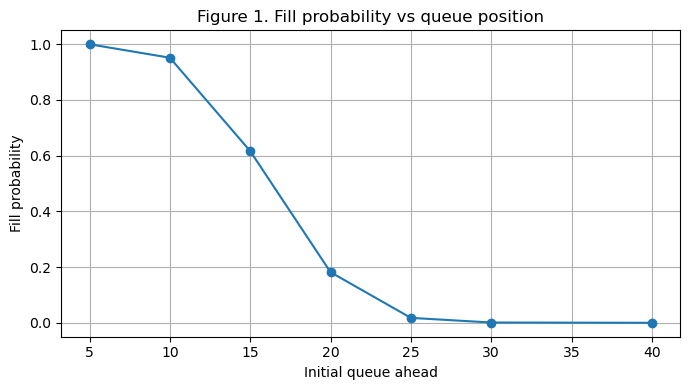

,queue_ahead,fill_probability
0,5,0.999667
1,10,0.951333
2,15,0.616333
3,20,0.181667
4,25,0.017667
5,30,0.001000
6,40,0.000000


In [3]:
queue_values = [5, 10, 15, 20, 25, 30, 40]

figure_1_records = []

for queue_ahead in queue_values:

    simulation_results = run_batch(

        n_runs=3000,

        queue_ahead=queue_ahead,

        imbalance=0.0,

        volatility=0.008,

        n_steps=80,

        post_fill_horizon=20,

        base_market_sell_rate=0.22,

        cancellation_rate=0.04,

    )

    figure_1_records.append({

        "queue_ahead": queue_ahead,

        "fill_probability":

            simulation_results["filled"].mean(),

    })

figure_1_data = pd.DataFrame(

    figure_1_records

)

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(

    figure_1_data["queue_ahead"],

    figure_1_data["fill_probability"],

    marker="o",

)

ax.set_xlabel("Initial queue ahead")

ax.set_ylabel("Fill probability")

ax.set_title(

    "Figure 1. Fill probability vs queue position"

)

ax.grid(True)

fig.tight_layout()

fig.savefig(

    FIGURE_DIR

    / "figure_1_fill_probability_vs_queue.png",

    dpi=300,

    bbox_inches="tight",

)

plt.show()

figure_1_data.to_csv(

    TABLE_DIR

    / "figure_1_fill_probability_vs_queue.csv",

    index=False,

)

figure_1_data

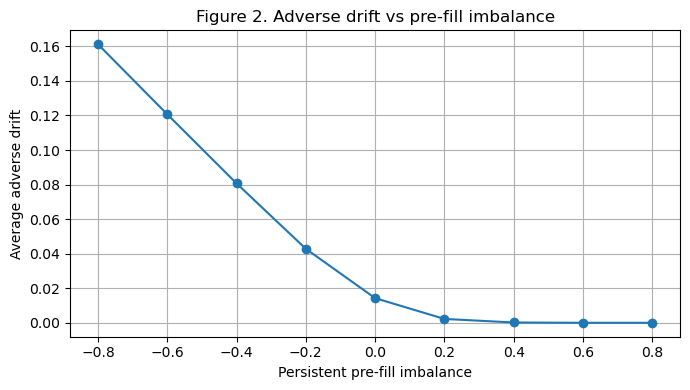

,initial_imbalance,fill_probability,average_post_fill_drift,average_adverse_drift,average_net_execution_value,bad_fill_ratio,number_of_fills
0,-0.8,1.000000,-0.161213,0.161213,-0.151213,1.000000,3000
1,-0.6,1.000000,-0.120677,0.120677,-0.110677,0.999667,3000
2,-0.4,1.000000,-0.080581,0.080686,-0.070581,0.980667,3000
3,-0.2,1.000000,-0.040528,0.042816,-0.030528,0.806333,3000
4,0.0,1.000000,-0.000096,0.014270,0.009904,0.401333,3000
5,0.2,0.999333,0.040527,0.002236,0.050527,0.074716,2998
6,0.4,0.996333,0.080925,0.000174,0.090925,0.006357,2989
7,0.6,0.983000,0.120449,0.000000,0.130449,0.000000,2949
8,0.8,0.948000,0.159920,0.000000,0.169920,0.000000,2844


In [4]:
imbalance_values = np.linspace(

    -0.8,

    0.8,

    9,

)

figure_2_records = []

for imbalance in imbalance_values:

    simulation_results = run_batch(

        n_runs=3000,

        queue_ahead=8,

        imbalance=float(imbalance),

        volatility=0.008,

        n_steps=100,

        post_fill_horizon=20,

        base_market_sell_rate=0.25,

        cancellation_rate=0.05,

        pressure_sensitivity=1.0,

        drift_coefficient=0.01,

    )

    filled_results = simulation_results.loc[

        simulation_results["filled"]

    ].copy()

    figure_2_records.append({

        "initial_imbalance":

            float(imbalance),

        "fill_probability":

            simulation_results["filled"].mean(),

        "average_post_fill_drift":

            filled_results[

                "post_fill_drift"

            ].mean(),

        "average_adverse_drift":

            filled_results[

                "adverse_drift"

            ].mean(),

        "average_net_execution_value":

            filled_results[

                "net_execution_value"

            ].mean(),

        "bad_fill_ratio":

            filled_results[

                "bad_fill"

            ].mean(),

        "number_of_fills":

            len(filled_results),

    })

figure_2_data = pd.DataFrame(

    figure_2_records

)

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(

    figure_2_data["initial_imbalance"],

    figure_2_data["average_adverse_drift"],

    marker="o",

)

ax.set_xlabel(

    "Persistent pre-fill imbalance"

)

ax.set_ylabel(

    "Average adverse drift"

)

ax.set_title(

    "Figure 2. Adverse drift vs pre-fill imbalance"

)

ax.grid(True)

fig.tight_layout()

fig.savefig(

    FIGURE_DIR

    / "figure_2_adverse_drift_vs_imbalance.png",

    dpi=300,

    bbox_inches="tight",

)

plt.show()

figure_2_data.to_csv(

    TABLE_DIR

    / "figure_2_adverse_drift_vs_imbalance.csv",

    index=False,

)

figure_2_data

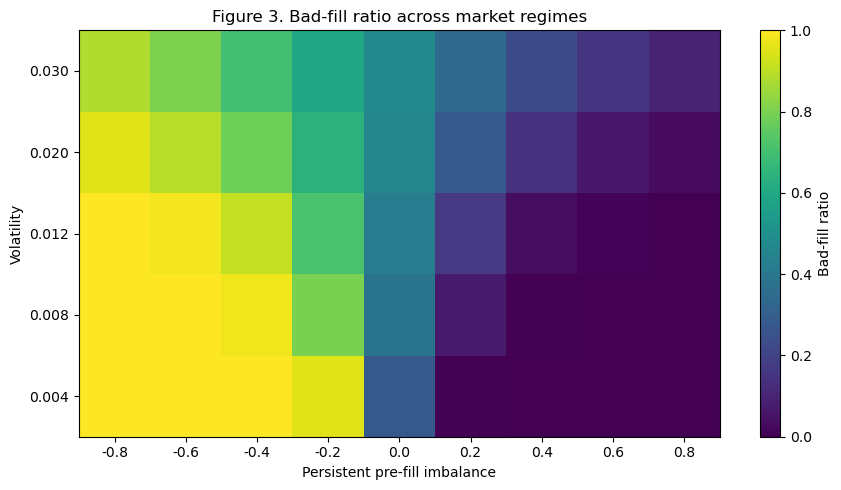

initial_imbalance,-0.8,-0.6,-0.4,-0.2,0.0,0.2,0.4,0.6,0.8
volatility,,,,,,,,,
0.004,1.0000,1.0000,1.0000,0.9505,0.2735,0.004004,0.000000,0.000000,0.000000
0.008,1.0000,1.0000,0.9795,0.8005,0.3850,0.072573,0.004523,0.000000,0.000000
0.012,0.9985,0.9815,0.9065,0.7130,0.4225,0.165165,0.033166,0.009179,0.000000
0.020,0.9515,0.8935,0.7790,0.6440,0.4545,0.275776,0.141709,0.068332,0.028541
0.030,0.8810,0.8010,0.7030,0.5960,0.4695,0.341341,0.233668,0.155533,0.094080


In [5]:
volatility_values = [

    0.004,

    0.008,

    0.012,

    0.020,

    0.030,

]

figure_3_records = []

for volatility in volatility_values:

    for imbalance in imbalance_values:

        simulation_results = run_batch(

            n_runs=2000,

            queue_ahead=8,

            imbalance=float(imbalance),

            volatility=float(volatility),

            n_steps=100,

            post_fill_horizon=20,

            base_market_sell_rate=0.25,

            cancellation_rate=0.05,

            pressure_sensitivity=1.0,

            drift_coefficient=0.01,

        )

        filled_results = simulation_results.loc[

            simulation_results["filled"]

        ].copy()

        figure_3_records.append({

            "volatility":

                float(volatility),

            "initial_imbalance":

                float(imbalance),

            "fill_probability":

                simulation_results[

                    "filled"

                ].mean(),

            "bad_fill_ratio":

                filled_results[

                    "bad_fill"

                ].mean(),

            "average_net_execution_value":

                filled_results[

                    "net_execution_value"

                ].mean(),

            "number_of_fills":

                len(filled_results),

        })

figure_3_data = pd.DataFrame(

    figure_3_records

)

bad_fill_matrix = figure_3_data.pivot(

    index="volatility",

    columns="initial_imbalance",

    values="bad_fill_ratio",

)

fig, ax = plt.subplots(figsize=(9, 5))

image = ax.imshow(

    bad_fill_matrix.values,

    aspect="auto",

    origin="lower",

)

ax.set_xticks(

    np.arange(

        len(bad_fill_matrix.columns)

    )

)

ax.set_xticklabels([

    f"{value:.1f}"

    for value

    in bad_fill_matrix.columns

])

ax.set_yticks(

    np.arange(

        len(bad_fill_matrix.index)

    )

)

ax.set_yticklabels([

    f"{value:.3f}"

    for value

    in bad_fill_matrix.index

])

ax.set_xlabel(

    "Persistent pre-fill imbalance"

)

ax.set_ylabel("Volatility")

ax.set_title(

    "Figure 3. Bad-fill ratio across market regimes"

)

fig.colorbar(

    image,

    ax=ax,

    label="Bad-fill ratio",

)

fig.tight_layout()

fig.savefig(

    FIGURE_DIR

    / "figure_3_bad_fill_ratio_heatmap.png",

    dpi=300,

    bbox_inches="tight",

)

plt.show()

figure_3_data.to_csv(

    TABLE_DIR

    / "figure_3_bad_fill_ratio_heatmap.csv",

    index=False,

)

bad_fill_matrix

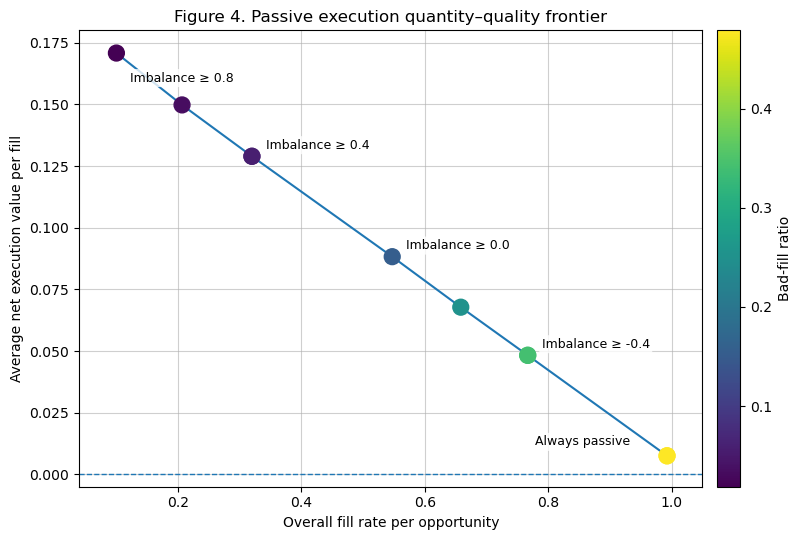

In [8]:
filter_thresholds = [

    -np.inf,

    -0.8,

    -0.6,

    -0.4,

    -0.2,

    0.0,

    0.2,

    0.4,

    0.6,

    0.8,

]

def summarize_filter_threshold(

    opportunities: pd.DataFrame,

    threshold: float,

) -> dict:

    if np.isneginf(threshold):

        trade_mask = pd.Series(

            True,

            index=opportunities.index,

        )

        label = "Always passive"

    else:

        trade_mask = (

            opportunities["imbalance"]

            >= threshold

        )

        label = f"Imbalance ≥ {threshold:.1f}"

    traded = opportunities.loc[

        trade_mask

    ].copy()

    filled = traded.loc[

        traded["filled"]

    ].copy()

    return {

        "threshold": threshold,

        "label": label,

        # Number of fills relative to all opportunities

        "overall_fill_rate":

            (

                trade_mask

                & opportunities["filled"]

            ).mean(),

        # Quality conditional on a fill

        "average_net_value_given_fill":

            filled[

                "net_execution_value"

            ].mean(),

        "bad_fill_ratio_given_fill":

            filled[

                "bad_fill"

            ].mean(),

        "average_adverse_drift_given_fill":

            filled[

                "adverse_drift"

            ].mean(),

        "number_traded": len(traded),

        "number_filled": len(filled),

    }

frontier_records = [

    summarize_filter_threshold(

        opportunities_data,

        threshold,

    )

    for threshold in filter_thresholds

]

frontier_data = pd.DataFrame(

    frontier_records

).sort_values(

    "overall_fill_rate"

)

fig, ax = plt.subplots(figsize=(8.5, 5.5))

scatter = ax.scatter(

    frontier_data["overall_fill_rate"],

    frontier_data["average_net_value_given_fill"],

    c=frontier_data["bad_fill_ratio_given_fill"],

    s=130,

    zorder=3,

)

ax.plot(

    frontier_data["overall_fill_rate"],

    frontier_data["average_net_value_given_fill"],

    linewidth=1.5,

    zorder=2,

)

# 只标记关键点，并手动控制偏移位置

label_offsets = {

    -np.inf: (-95, 10),   # Always passive

    -0.4: (10, 8),

    0.0: (10, 8),

    0.4: (10, 8),

    0.8: (10, -18),

}

for _, row in frontier_data.iterrows():

    threshold = row["threshold"]

    matched_key = None

    if np.isneginf(threshold):

        matched_key = -np.inf

    elif threshold in [-0.4, 0.0, 0.4, 0.8]:

        matched_key = threshold

    if matched_key is None:

        continue

    label = (

        "Always passive"

        if np.isneginf(threshold)

        else f"Imbalance ≥ {threshold:.1f}"

    )

    ax.annotate(

        label,

        (

            row["overall_fill_rate"],

            row["average_net_value_given_fill"],

        ),

        xytext=label_offsets[matched_key],

        textcoords="offset points",

        fontsize=9,

        ha="left",

        va="center",

        bbox={

            "boxstyle": "round,pad=0.2",

            "facecolor": "white",

            "edgecolor": "none",

            "alpha": 0.8,

        },

    )

ax.axhline(

    0.0,

    linestyle="--",

    linewidth=1,

)

ax.set_xlabel("Overall fill rate per opportunity")

ax.set_ylabel("Average net execution value per fill")

ax.set_title("Figure 4. Passive execution quantity–quality frontier")

# 给文字留出空间

ax.set_xlim(0.04, 1.05)

ax.set_ylim(-0.005, 0.18)

ax.grid(True, alpha=0.6)

colorbar = fig.colorbar(

    scatter,

    ax=ax,

    pad=0.02,

)

colorbar.set_label("Bad-fill ratio")

fig.tight_layout()

fig.savefig(

    FIGURE_DIR / "figure_4_execution_frontier.png",

    dpi=300,

    bbox_inches="tight",

)

plt.show()

In [9]:
print("Saved figures:")

for path in sorted(

    FIGURE_DIR.glob("*.png")

):

    print("-", path.name)

print("\nSaved tables:")

for path in sorted(

    TABLE_DIR.glob("*.csv")

):

    print("-", path.name)

Saved figures:
- fig1_fill_probability_vs_queue_position.png
- fig2_post_fill_drift_vs_imbalance.png
- figure_1_fill_probability_vs_queue.png
- figure_2_adverse_drift_vs_imbalance.png
- figure_3_bad_fill_ratio_heatmap.png
- figure_4_execution_frontier.png
- figure_4_strategy_tradeoff.png

Saved tables:
- figure_1_fill_probability_vs_queue.csv
- figure_2_adverse_drift_vs_imbalance.csv
- figure_3_bad_fill_ratio_heatmap.csv
- figure_4_execution_frontier.csv
- figure_4_strategy_tradeoff.csv
